# Visualization for train images

class1.tif
shape: (560, 600)
unique values: [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127. 128. 129.]

class2.tif
shape: (560, 600)
unique values: [  0. 130. 131.]



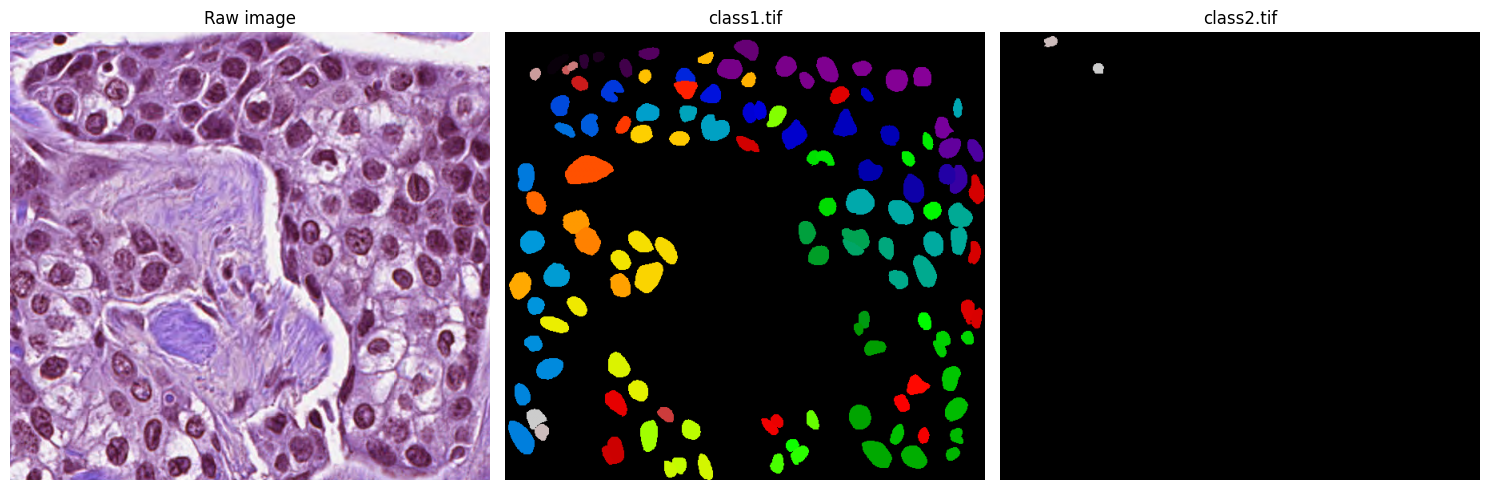

In [6]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
import json
from PIL import Image
from pycocotools import mask as mask_utils


def open_tif(path):
    """Open tif correctly (supports medical / multi-bit images)"""
    return tiff.imread(path)


def show_image_and_masks(folder_path):
    folder = Path(folder_path)

    image_path = folder / "image.tif"
    mask_paths = sorted(folder.glob("class*.tif"))

    image = open_tif(image_path)
    masks = [open_tif(p) for p in mask_paths]

    n_cols = 1 + len(masks)

    plt.figure(figsize=(5 * n_cols, 5))

    # Image
    plt.subplot(1, n_cols, 1)
    plt.imshow(image)
    plt.title("Raw image")
    plt.axis("off")

    # Masks
    for i, (mask, path) in enumerate(zip(masks, mask_paths), start=2):
        plt.subplot(1, n_cols, i)

        # IMPORTANT pour affichage
        plt.imshow(mask, cmap="nipy_spectral")

        plt.title(path.name)
        plt.axis("off")

        print(f"{path.name}")
        print("shape:", mask.shape)
        print("unique values:", np.unique(mask))
        print()

    plt.tight_layout()
    plt.show()


# TEST
show_image_and_masks("hw3-data-release/train/0088d6cd-fcbd-4037-babf-74abd3c82204")

# Visualization for predicted masks

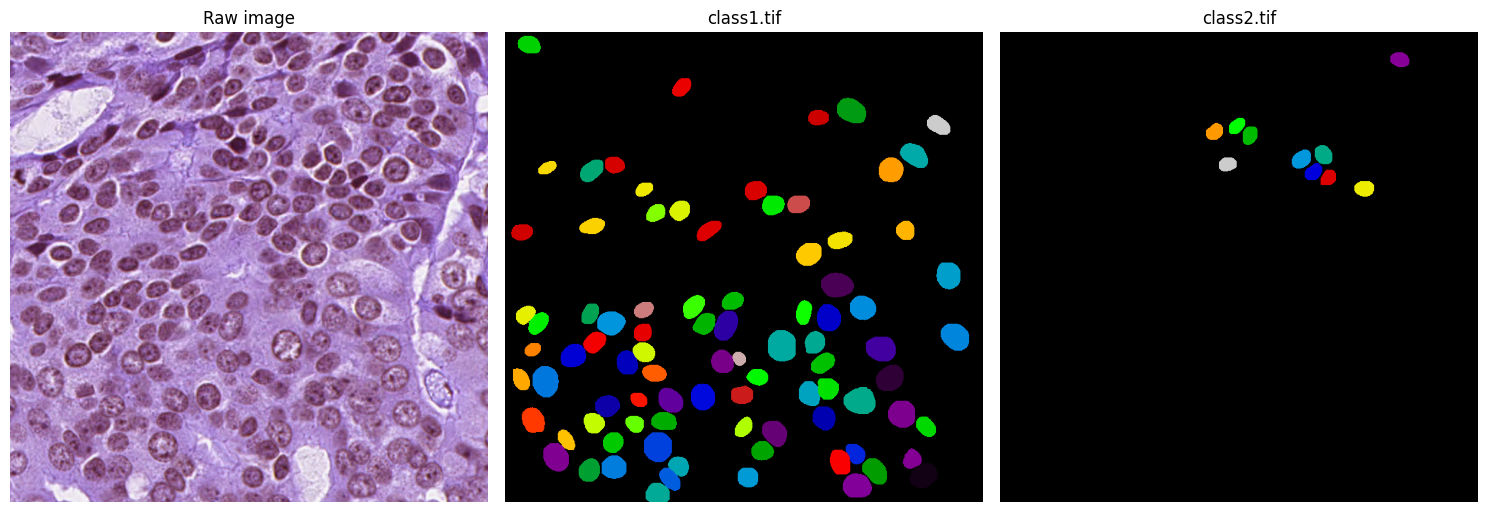

In [13]:
# Paths
json_path = "test-results.json"
test_dir = "hw3-data-release/test_release"
mapping_path = "hw3-data-release/test_image_name_to_ids.json"

# -------------------------
# Load files
# -------------------------
with open(json_path, "r") as f:
    predictions = json.load(f)

with open(mapping_path, "r") as f:
    image_infos = json.load(f)

id_to_filename = {
    item["id"]: item["file_name"]
    for item in image_infos
}

# -------------------------
# Choose image
# -------------------------
image_id = 4
image_name = id_to_filename[image_id]
image_path = f"{test_dir}/{image_name}"

image = Image.open(image_path).convert("RGB")
image_np = np.array(image)

H, W = image_np.shape[:2]

# -------------------------
# Parameters
# -------------------------
score_threshold = 0.5
num_classes = 4

preds = [
    p for p in predictions
    if p["image_id"] == image_id and p["score"] >= score_threshold
]

# -------------------------
# Build masks only for classes
# that contain predictions
# -------------------------
class_instance_masks = {}

for class_id in range(1, num_classes + 1):

    class_preds = [
        p for p in preds
        if p["category_id"] == class_id
    ]

    # Skip empty classes
    if len(class_preds) == 0:
        continue

    mask_map = np.zeros((H, W), dtype=np.int32)

    for instance_id, pred in enumerate(class_preds, start=1):

        rle = pred["segmentation"].copy()

        if isinstance(rle["counts"], str):
            rle["counts"] = rle["counts"].encode("utf-8")

        mask = mask_utils.decode(rle)

        mask_map[mask == 1] = instance_id

    class_instance_masks[class_id] = mask_map

# -------------------------
# Dynamic subplot number
# -------------------------
n_plots = 1 + len(class_instance_masks)

fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

# If only one subplot after raw image
if n_plots == 2:
    axes = np.array(axes)

# -------------------------
# Raw image
# -------------------------
axes[0].imshow(image_np)
axes[0].set_title("Raw image")
axes[0].axis("off")

# -------------------------
# Display only non-empty classes
# -------------------------
for idx, (class_id, mask) in enumerate(class_instance_masks.items(), start=1):

    masked_display = np.ma.masked_where(mask == 0, mask)

    axes[idx].imshow(np.zeros((H, W)), cmap="gray")
    axes[idx].imshow(masked_display, cmap="nipy_spectral")

    axes[idx].set_title(f"class{class_id}.tif")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()